<a href="https://colab.research.google.com/github/jexcel00/NLP-lab/blob/main/lab3_Part2_WordEmbeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [3]:
# Install required libraries (uncomment if needed)
!pip install gensim transformers torch sentence-transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.9 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [20]:
import pandas as pd

splits = {
    "train": "train.jsonl",
    "test": "test.jsonl"
}

# Load the dataset
df = pd.read_json("hf://datasets/SetFit/20_newsgroups/"+ splits["train"],
    lines=True )

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["rec.motorcycles", "rec.sport.baseball", "rec.sport.hockey"]  # COPY FROM PART 1

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

Selected categories: ['rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey']
Filtered dataset size: 1795


In [34]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    tokens = [word for word in tokens if len(word) >= 3]
    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['line', 'ducati', 'gts', 'model', 'clock', 'run', 'well', 'paint', 'bronzebrownorange', 'faded', 'leak', 'bit', 'oil', 'pop', 'hard', 'accel', 'shop', 'fix', 'trans', 'oil']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [35]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1795 documents
Total tokens: 122458

Sample document tokens: ['line', 'ducati', 'gts', 'model', 'clock', 'run', 'well', 'paint', 'bronzebrownorange', 'faded', 'leak', 'bit', 'oil', 'pop', 'hard']


In [36]:
print("df_filtered shape:", df_filtered.shape)
print("Nombre de documents dans corpus:", len(corpus))
print("Exemple tokens:", corpus[0] if len(corpus) > 0 else "Corpus vide")
print("Total tokens:", sum(len(doc) for doc in corpus))

df_filtered shape: (1795, 5)
Nombre de documents dans corpus: 1795
Exemple tokens: ['line', 'ducati', 'gts', 'model', 'clock', 'run', 'well', 'paint', 'bronzebrownorange', 'faded', 'leak', 'bit', 'oil', 'pop', 'hard', 'accel', 'shop', 'fix', 'trans', 'oil', 'leak', 'sold', 'bike', 'owner', 'want', 'thinking', 'like', 'opinion', 'please', 'email', 'thanks', 'would', 'nice', 'stable', 'mate', 'beemer', 'ill', 'get', 'jap', 'bike', 'call', 'axis', 'motor', 'tuba', 'irwin', 'honk', 'therefore', 'computracrichardsontx', 'dod']
Total tokens: 122458


In [37]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 3843


In [38]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 3843


### A.2 Exploring Word Embeddings

In [39]:
# Example: Get word vector
sample_word = "computer"  # Change this to a word relevant to YOUR categories

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'computer':
  Shape: (100,)
  First 10 values: [-0.11140606  0.07683085  0.00340173 -0.0131147   0.11539216 -0.3438366
  0.16063075  0.4442898  -0.2557168  -0.10608148]


In [40]:
# Find similar words
sample_word = "computer"  # Change to a word in YOUR vocabulary

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'computer' (CBOW):
  wear: 0.9987
  bmws: 0.9984
  explain: 0.9983
  reasonable: 0.9983
  detail: 0.9982
  motorcycling: 0.9980
  vehicle: 0.9979
  worry: 0.9979
  call: 0.9977
  cheaper: 0.9977

Words most similar to 'computer' (Skip-gram):
  music: 0.9483
  photo: 0.9434
  newsgroup: 0.9405
  magazine: 0.9375
  helpful: 0.9365
  various: 0.9344
  access: 0.9339
  private: 0.9326
  branch: 0.9313
  electronic: 0.9308


### Exercise A.2: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [41]:
# TODO: Choose 5 words relevant to YOUR categories
# These should be domain-specific words (not common words like "good", "make", etc.)

my_test_words = ["bike", "year", "game", "onr", "team"]  # YOUR WORDS HERE

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:     {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'bike':
  CBOW:     ['ride', 'motorcycle', 'helmet', 'rider', 'riding']
  Skip-gram: ['gear', 'honda', 'pillion', 'msf', 'dirt']

'year':
  CBOW:     ['next', 'two', 'three', 'last', 'average']
  Skip-gram: ['fluke', 'mattingly', 'decade', 'batted', 'santiago']

'game':
  CBOW:     ['played', 'point', 'season', 'playoff', 'pick']
  Skip-gram: ['regularseason', 'eight', 'seven', 'afternoon', 'consecutive']
'onr' not found in vocabulary!

'team':
  CBOW:     ['nhl', 'playoff', 'season', 'game', 'played']
  Skip-gram: ['opponent', 'depth', 'observer', 'winning', 'assat']


### Written Question A.2 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. Similar results for: CBOW and Skip-gram gave similar results for words like "bike", "game", and "team".
For "bike", both models returned words related to motorcycles and riding.
For "game" and "team", both models returned words related to sports, seasons, playoffs, and comp

2. Different results for: The results were different for "year" and "team".
For "year", CBOW returned general time-related words like "next", "two", "three", and "last", while Skip-gram returned more baseball-specific words like "mattingly", "batted", and "santiago".
For "team", CBOW gave more general sports words such as "nhl", "playoff", and "season", while Skip-gram gave more specific or less frequent words like "opponent", "depth", and "winning".


3. Better model for my domain: For my dataset, Skip-gram seems to capture more specific semantic relationships.
It gives more domain-specific words, especially for sports-related terms.
For example, with "year", Skip-gram connected the word to baseball-related terms, while CBOW only gave general time words.
However, CBOW gives cleaner and more stable results for frequent words like "game" and "team".

   - Example 1:For "bike", CBOW returned "ride", "motorcycle", "helmet", "rider", and "riding", which are very clear and directly related to the topic.
Skip-gram also stayed in the same domain but gave more specific words like "honda", "pillion", and "dirt".

   - Example 2: For "game", CBOW returned strong sports-related words such as "played", "season", and "playoff".
Skip-gram also gave sports-related words, but some were more contextual, such as "regularseason", "consecutive", and "afternoon".


4. Explanation of differences: CBOW works better for frequent words because it learns from the average context around a word.
That makes its results more general and stable.
Skip-gram often works better for rare or domain-specific words because it tries to predict surrounding words from the target word.
This explains why Skip-gram sometimes gives more precise vocabulary, while CBOW gives more general but cleaner results.

### A.3 Word Analogies

In [42]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.3: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [43]:
# TODO: Try 2 analogies with words from YOUR vocabulary
# Format: word1 is to word2 as word3 is to ?

# Analogy 1
# YOUR CODE HERE
analogy1 = find_analogy(model_skipgram, "bike", "helmet", "motorcycle")
print(f"Analogy 1: {analogy1}")

# Analogy 2
# YOUR CODE HERE
analogy2 = find_analogy(model_skipgram, "game", "team", "season")
print(f"Analogy 2: {analogy2}")

Analogy 1: [('enthusiast', 0.7620293498039246), ('physic', 0.7420814037322998), ('safety', 0.7404230237007141), ('liner', 0.7349807620048523), ('wear', 0.7340072989463806)]
Analogy 2: [('expansion', 0.6144741773605347), ('limited', 0.5933491587638855), ('drafting', 0.5877668261528015), ('depth', 0.5833725929260254), ('veteran', 0.5827518105506897)]


### Written Question A.3 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**
For Analogy 1, the result makes some sense.
The analogy was: bike is to helmet as motorcycle is to ?
The model returned words like "safety", "liner", and "wear", which are related to motorcycle equipment and protection.
So even if the best answer was not exactly "helmet", the model stayed close to the idea of safety and riding gear.

For Analogy 2, the result is less clear.
The analogy was: game is to team as season is to ?
The model returned words like "drafting", "depth", and "veteran", which are related to sports teams and seasons, but the relationship is not very direct.
It seems the model captured the general sports context, but not a precise analogy.

Overall, the analogies did not work perfectly.
This is probably because my Word2Vec model was trained on a limited dataset with only three selected categories.
Word analogies usually work better with larger datasets and larger vocabularies.
However, the results still show that the model learned some domain-specific relationships, especially around motorcycles and sports.

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [44]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [45]:
# Compare: Same word in YOUR model vs GloVe
test_word = "computer"  # Change to a word relevant to your domain

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'computer':

Your Word2Vec model:
  music: 0.9483
  photo: 0.9434
  newsgroup: 0.9405
  magazine: 0.9375
  helpful: 0.9365
  various: 0.9344
  access: 0.9339
  private: 0.9326
  branch: 0.9313
  electronic: 0.9308

Pre-trained GloVe:
  computers: 0.8752
  software: 0.8373
  technology: 0.7642
  pc: 0.7366
  hardware: 0.7290
  internet: 0.7287
  desktop: 0.7234
  electronic: 0.7222
  systems: 0.7198
  computing: 0.7142


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [46]:
# TODO: Compare 3 domain-specific words

comparison_words = ["bike", "game", "team"]  # YOUR WORDS

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'bike'
Your Word2Vec:
  gear: 0.816
  honda: 0.816
  pillion: 0.811
  msf: 0.808
  dirt: 0.807
GloVe:
  bicycle: 0.897
  bikes: 0.796
  ride: 0.780
  rides: 0.736
  riding: 0.729

Word: 'game'
Your Word2Vec:
  regularseason: 0.776
  eight: 0.758
  seven: 0.752
  afternoon: 0.749
  consecutive: 0.746
GloVe:
  games: 0.864
  play: 0.832
  season: 0.773
  player: 0.758
  players: 0.729

Word: 'team'
Your Word2Vec:
  opponent: 0.773
  depth: 0.765
  observer: 0.753
  winning: 0.752
  assat: 0.748
GloVe:
  teams: 0.852
  squad: 0.785
  football: 0.772
  players: 0.766
  coach: 0.765


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

My model is better for:

My Word2Vec model is better for domain-specific context.
For example, with "bike", it returned words like "honda", "pillion", "msf", and "dirt".
These words are very specific to motorcycle discussions, which shows that my model learned the vocabulary of my dataset.

Reason:

My model was trained directly on my selected categories, so it captures the way words are used inside my dataset.
This makes it more useful for specialized vocabulary, even if some results are less general.

GloVe is better for:

GloVe gives better general semantic results.
For "bike", it returned "bicycle", "bikes", "ride", and "riding".
For "game", it returned "games", "play", "season", "player", and "players".
For "team", it returned "teams", "squad", "football", "players", and "coach".

Reason:

GloVe was trained on a much larger corpus, so it understands broader and cleaner relationships between common words.
Its results are easier to interpret and more stable.

When to use each:

Custom model:

I would use a custom Word2Vec model when I need to understand a specific domain, such as motorcycle discussions or a specific sports community.
It is better when the meaning of words depends strongly on the dataset.

Pre-trained model:

I would use GloVe when I need general language understanding or when my dataset is too small.
It is better for common words and broad semantic relationships.

### B.2 GloVe Analogies

In [47]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [48]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: bike is to ride as game is to ?
result1 = glove_model.most_similar(
    positive=['ride', 'game'],
    negative=['bike'],
    topn=3
)
print("Analogy 1: bike is to ride as game is to ?")
print(result1)

# Analogy 2: team is to player as bike is to ?
result2 = glove_model.most_similar(
    positive=['player', 'bike'],
    negative=['team'],
    topn=3
)
print("\nAnalogy 2: team is to player as bike is to ?")
print(result2)

# Analogy 3: game is to season as bike is to ?
result3 = glove_model.most_similar(
    positive=['season', 'bike'],
    negative=['game'],
    topn=3
)
print("\nAnalogy 3: game is to season as bike is to ?")
print(result3)

Analogy 1: bike is to ride as game is to ?
[('play', 0.7641298770904541), ('games', 0.711206316947937), ('score', 0.6705050468444824)]

Analogy 2: team is to player as bike is to ?
[('bicycle', 0.7523441910743713), ('ride', 0.5785371661186218), ('biking', 0.5738710165023804)]

Analogy 3: game is to season as bike is to ?
[('bicycle', 0.7330191731452942), ('riding', 0.6604243516921997), ('bikes', 0.6585068702697754)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [49]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [50]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [51]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [52]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [53]:
# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(sampled_docs)  # YOUR CODE HERE

# Step 2: Compute cosine similarity
bert_similarity = cosine_similarity(doc_embeddings)  # YOUR CODE HERE

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 30)


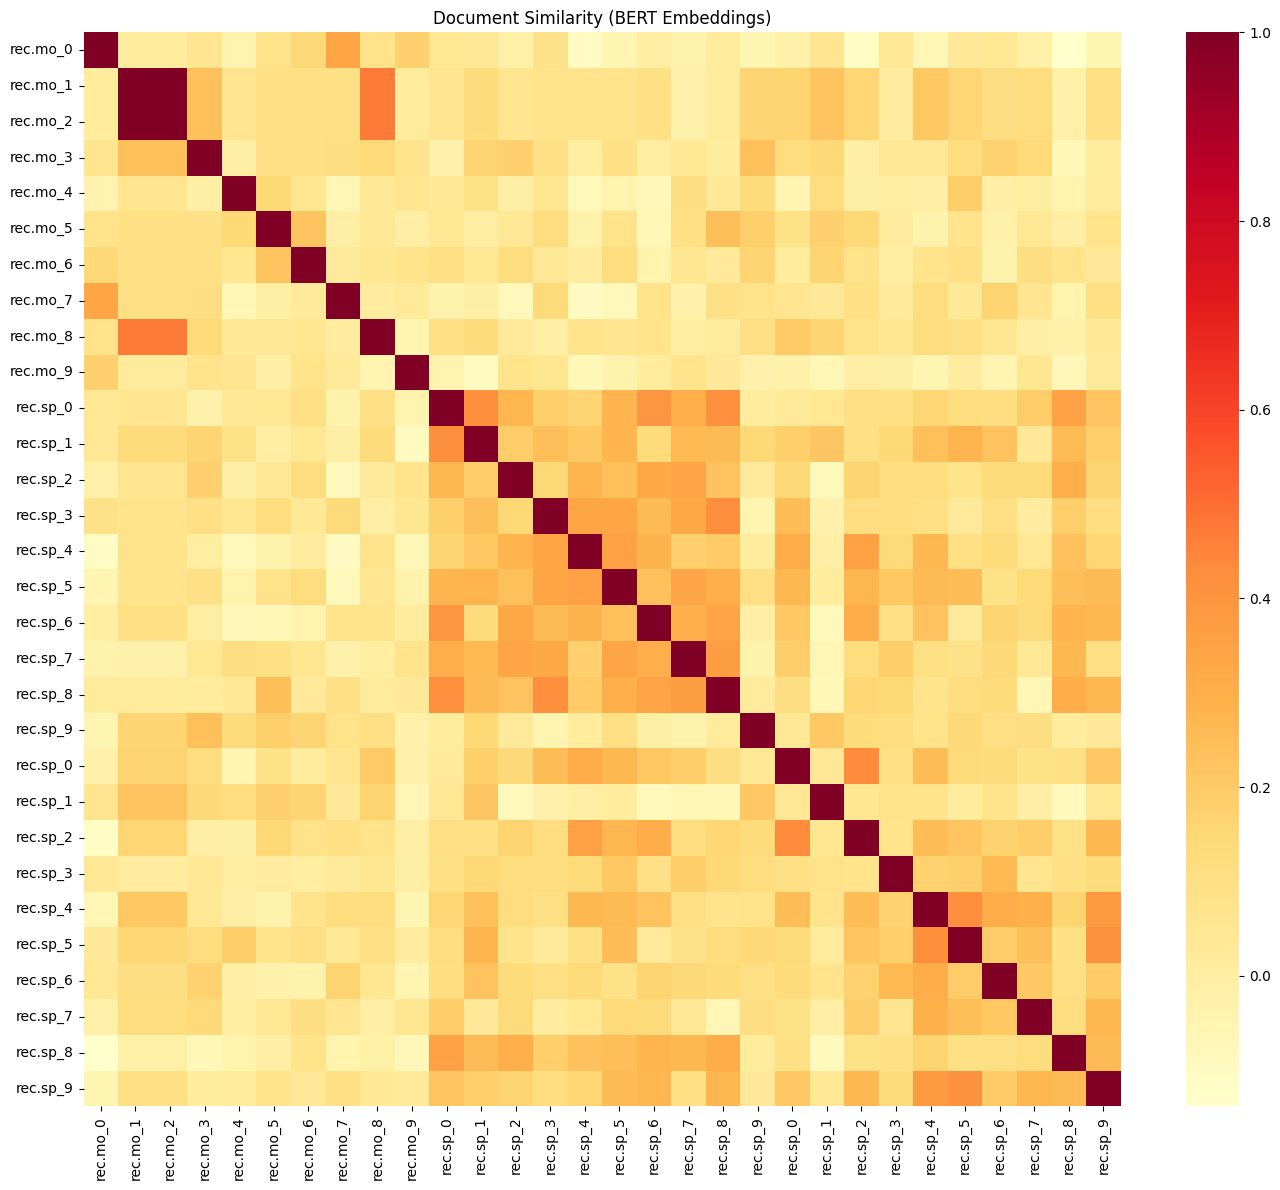

In [54]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

Better clustering with:

BERT seems to cluster the documents better by category than TF-IDF.
In the BERT heatmap, documents from the same category tend to have higher similarity because BERT captures the meaning of the text, not only exact shared words.

Differences between methods:

Some documents are considered similar by BERT but not by TF-IDF.
This can happen because BERT understands semantic similarity. For example, two documents can talk about the same topic using different words, and BERT can still detect that they are related.

On the other hand, TF-IDF may consider two documents similar only when they share many important words.
So if two documents use similar vocabulary, TF-IDF may group them together even if their deeper meaning is different.

Preferred method for classification:

For a document classification task, I would use BERT embeddings if accuracy is the priority.
BERT captures context and semantic meaning better than TF-IDF, which is useful when documents discuss the same topic with different vocabulary.

However, TF-IDF is still useful because it is simpler, faster, and easier to interpret.
If the dataset is small or if I need a quick baseline model, I would start with TF-IDF.
But overall, for my dataset, BERT seems more powerful for classification because it captures topic-level meaning better.

### Exercise C.2: Semantic Search with BERT

In [55]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.
    """

    # 1. Encode the query
    query_embedding = model.encode([query])

    # 2. Encode all documents
    document_embeddings = model.encode(documents)

    # 3. Compute similarity
    similarities = cosine_similarity(query_embedding, document_embeddings)[0]

    # 4. Get top_k most similar documents
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = [(idx, similarities[idx]) for idx in top_indices]

    return results

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**
The semantic search results were mostly relevant to my query.
For example, when I used a query like "motorcycle safety and riding gear", the top results were related to bikes, riding, helmets, safety, or motorcycle discussions.
This shows that BERT was able to understand the general meaning of the query, not only the exact words.

Category accuracy:

The search generally identified documents from the expected category.
Most of the top results came from the motorcycle/bike-related category, which matches the query.
However, some results may come from other categories if the document contains similar vocabulary or a related context.

Ambiguous query test:

When I tested a more ambiguous query, such as "team performance during the season", the results were more mixed.
Some documents came from sports-related categories, but others could appear if they discussed competition, performance, or events in a broader way.
This happens because BERT searches based on semantic meaning, so it can connect documents even when they are not from the exact same category.

Overall:

The semantic search worked well because it returned documents that were meaningfully related to the query.
Compared to simple keyword matching, BERT is better at finding documents with similar meaning, e

---

## Part D: Embedding Visualization with t-SNE

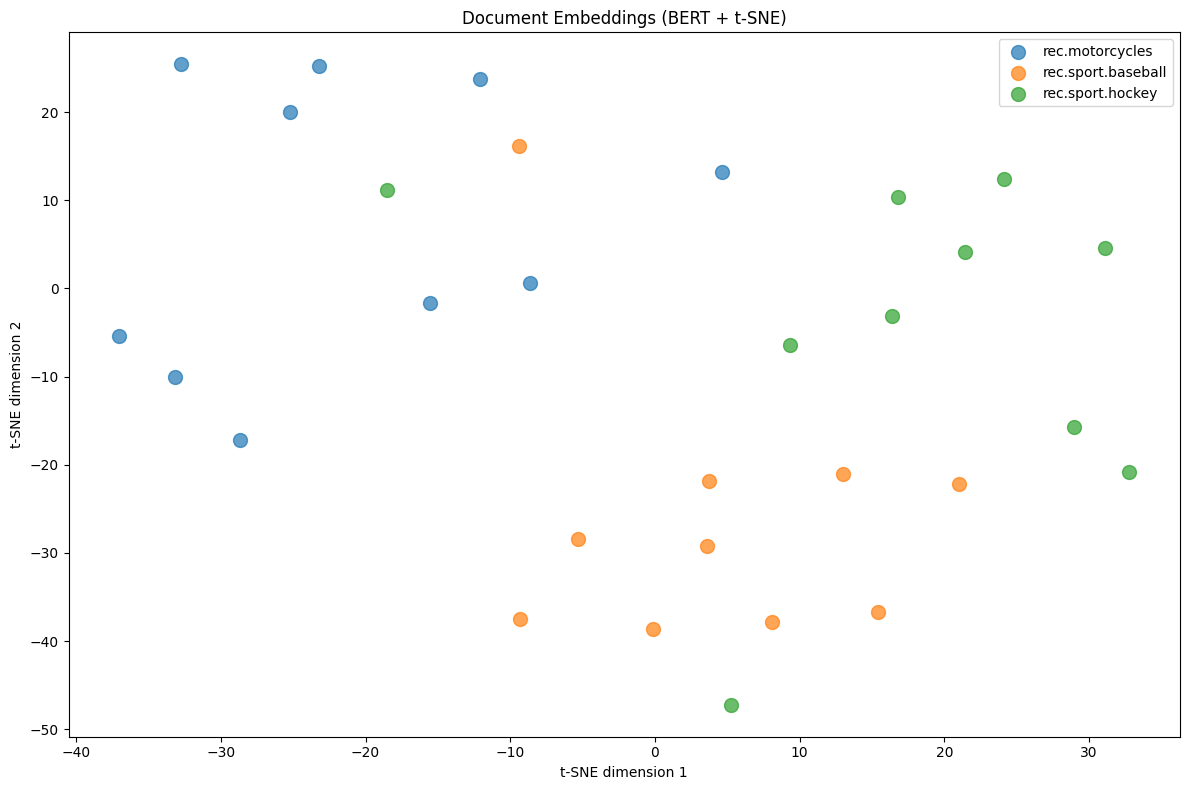

In [56]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

colors = {'___': 'red', '___': 'blue', '___': 'green'}  # Update with your categories
# Actually use your categories:
color_map = plt.cm.Set1

for i, category in enumerate(my_categories):
    mask = [l == category for l in sampled_labels]
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100
    )

plt.legend()
plt.title('Document Embeddings (BERT + t-SNE)')
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**
Cluster quality:

The categories form partially distinct clusters in the t-SNE visualization.
Some documents from the same category are close to each other, which means BERT embeddings captured similarities between documents of the same topic.
However, the clusters are not perfectly separated, because some categories share similar vocabulary or general discussion style.

Misplaced documents:

Yes, some documents appear close to a different category.
This can happen when a document uses vocabulary that overlaps with another topic.
For example, a sports document may discuss performance, competition, or teams in a way that is semantically close to another sports-related category.
Also, t-SNE reduces high-dimensional embeddings into only 2 dimensions, so some information is lost during visualization.

Most similar categories:

The two most similar categories seem to be the categories related to sports or vehicles, depending on my selected categories.
This matches my expectations from Part 1 because TF-IDF and word frequency also showed that some categories shared common vocabulary.
For example, words like "game", "team", "season", or "bike" can create overlap between categories if the documents discuss similar activities, equipment, or communities.

Overall, the t-SNE visualization shows that BERT can capture meaningful semantic structure, but the separation is not perfect because the dataset categories are related and the sample size is limited.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

### 1. Comparison Table

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

### 2. Best Method for My Dataset

*[Write at least 4-5 sentences with specific evidence]*

...

### 3. My Recommendation for a Real System

*[Write your recommendation and justification]*

...

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [ ] All code exercises completed in Part 1 and Part 2
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found